# Marketing Campaigns - A/B Testing & Regression Analysis

---
## 1. Project Overview & Data Description

---

### 1.1 Context & Business Objectives
This dataset represents a structured, year-long A/B testing and marketing attribution experiment conducted across the entire calendar year of 2019 (365 daily observations). The primary objective of this project is to evaluate, compare, and model the performance dynamics of two distinct digital advertising channels: **Facebook Ads** and **Google AdWords**.

By leveraging statistical hypothesis testing (A/B testing frameworks) and regression analysis, the analytical goal is to move beyond superficial metrics and evaluate true channel efficiency. The findings will establish data-driven recommendations on budget allocation, funnel optimization, and cost-per-acquisition (CPA) minimization.

---

### 1.2 The Marketing Funnel Framework
To extract meaningful business intelligence, the features in this dataset are analyzed through a standard four-stage marketing acquisition funnel:

```

[Awareness: Views] 

        |
        
[Engagement: Clicks (CTR)]

        |
        
[Conversion: Actions (CR)]

        |
        
[Efficiency: Cost (CPC)]

```

1. **Top of the Funnel: Awareness (Ad Views)**

    * Quantifies total audience reach and brand exposure.
    * **What it is:** How many times did your ad appear on someone's screen?
    * **The Strategy:** This measures pure reach. Looking at your descriptive stats, AdWords showed the ad about 4,700 times a day, while Facebook only showed it 2,100 times. But reach alone doesn't pay the bills; we need to see what happens next.

2. **Middle of the Funnel: Engagement (Clicks & CTR)**

    * Evaluates ad relevance, creative strength, and user intent.
    * **What it is:** Of the people who saw the ad, how many actually clicked it?
    * **Click-Through Rate (CTR):** This is your quality check. If Facebook has a higher CTR than AdWords, it indicates that the Facebook ads are more relevant or appealing to the people seeing them.

3. **Bottom of the Funnel: The Goal (Conversions & Conv. Rate)**

    * Measures the ultimate efficacy of the landing page and user intent in driving desired business actions.
    * **What it is:** Of the people who clicked through to your website, how many actually took the desired action (e.g., made a purchase or signed up)?
    * **Conversion Rate:** This is where the magic happens. It tells you where users are dropping off in the journey from merely browsing to actually becoming a customer.

4. **Efficiency (Cost Optimization):** Cross-references performance against expenditure to determine financial viability and ROI.

    * Cross-references performance against expenditure to determine financial viability and ROI.
    * **What it is:** How much did it cost you to get those results?
    * **Cost per Click (CPC):** This reveals your true efficiency. One platform might drive a ton of traffic, but if you are paying 5 per click there versus 2 per click on the other platform, your profitability takes a hit.

**The "So What?" for your Project**

When you start running your regression analysis and hypothesis tests in your notebook, your objective is to find the hidden story. For example, your data might reveal that while AdWords gets a much higher volume of views, Facebook drives cheaper, higher-quality conversions. If that's the case, your final recommendation would be to shift more budget toward Facebook.

---

### 1.3 Feature Dictionary & Mathematical Formulations

The dataset comprises **365 observations** (one for each day of the year), tracking key visibility, engagement, conversion, and cost metrics across a daily tracking grain.

#### Core Structural & Volume Metrics

* **Date:** The tracking date, ranging from January 1st, 2025, to December 31st, 2025 (`Object` data type initially, to be converted to `Datetime`).
* **Ad Campaign Name (`Facebook Ad Campaign` / `AdWords Ad Campaign`):** Categorical identifiers representing monthly variations of the campaigns (e.g., `FB_Jan25`, `AW_Dec25`).
* **Ad Views (`Int64`):** The total number of times the advertisement was displayed to users (Impressions/Awareness).
* **Ad Clicks (`Int64`):** The total number of recorded clicks on the advertisement (Engagement).
* **Ad Conversions (`Int64`):** The total number of successful target actions (e.g., sign-ups, purchases) completed by users post-click.
* **Cost per Ad (`Object`):** The total daily financial expenditure allocated to running the respective campaign platform (formatted as string with a `$` prefix).

#### Calculated Performance & Efficiency Indicators

* **Click-Through Rate (CTR):** Measures the baseline efficiency of the ad creative in capturing user attention and generating traffic from views.
$$\text{CTR} = \frac{\text{Ad Clicks}}{\text{Ad Views}}$$

* **Conversion Rate (CVR):** Evaluates the bottom-of-funnel effectiveness of the target landing page or product offer in turning engaged traffic into completions.
$$\text{Conversion Rate} = \frac{\text{Ad Conversions}}{\text{Ad Clicks}}$$

* **Cost per Click (CPC):** Represents the unit cost of acquisition for each engaged visitor, determining the financial efficiency of the campaign spend.
$$\text{CPC} = \frac{\text{Cost per Ad}}{\text{Ad Clicks}}$$

---

#### Why do we need same-day data for A/B testing?

In an ideal experiment, you want to change only one thing (the ad variant or platform) while keeping everything else exactly the same.

Using same-day data (or syncing your observations strictly by day) is crucial in A/B testing because it isolates your experiment from external noise. If you compare Facebook data from a Monday to AdWords data from a Saturday, or Facebook data from January to AdWords data from December, your results will be heavily skewed by confounding variables.

* **Isolating the Experiment:** It ensures that any difference in performance metrics (such as CTR or Conversion Rate) is driven entirely by the platform itself (Facebook vs. AdWords), keeping **Time** as a strict control constant.

* **Controlling for External Noise:** It neutralizes external "confounding variables" that skew human behavior on a daily basis, such as weekly cyclicality (weekdays vs. weekends) and seasonal impacts (holidays, paydays, or major external events).

* **Reflecting Real-Time Market Realities:** It ensures both campaigns are subjected to identical macroeconomic and auction pressures on any given day, such as a sudden competitor budget spike that inflates the market's Cost per Click (CPC).

---

## 2. Data Preprocessing & Cleaning

---

Before proceeding with exploratory data analysis, A/B testing, or regression modeling, the dataset requires structural parsing and data type casting.


In [144]:
# Import the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import scipy.stats as st
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import coint
import warnings
warnings.filterwarnings('ignore')

In [112]:
# Loading the dataset
df = pd.read_csv('marketing_campaign_2025.csv')

In [113]:
df.head()

,Date,Facebook Ad Campaign,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,Cost per Facebook Ad,Facebook Click-Through Rate (Clicks / View),Facebook Conversion Rate (Conversions / Clicks),Facebook Cost per Click (Ad Cost / Clicks),AdWords Ad Campaign,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions,Cost per AdWords Ad,AdWords Click-Through Rate (Clicks / View),AdWords Conversion Rate (Conversions / Click),AdWords Cost per Click (Ad Cost / Clicks)
0,1/1/2025,FB_Jan25,2343,49,13,$214,2.09%,26.53%,$4.36,AW_Jan25,4506,54,5,$108,1.2%,9.26%,$2.0
1,1/2/2025,FB_Jan25,2331,42,10,$93,1.8%,23.81%,$2.22,AW_Jan25,4766,63,6,$201,1.32%,9.52%,$3.19
2,1/3/2025,FB_Jan25,2314,51,13,$140,2.2%,25.49%,$2.74,AW_Jan25,4740,60,3,$148,1.27%,5.0%,$2.47
3,1/4/2025,FB_Jan25,3254,62,13,$300,1.91%,20.97%,$4.83,AW_Jan25,4530,61,7,$154,1.35%,11.48%,$2.53
4,1/5/2025,FB_Jan25,2254,41,12,$103,1.82%,29.27%,$2.51,AW_Jan25,3799,49,5,$104,1.29%,10.2%,$2.12


---

### 2.1 Handling Formatting and Type Conversions

* **Date Alignment:** Convert the `Date` column from a string (`object`) datatype to a uniform `datetime64` format.

* **String Stripping:** Clean numeric columns (such as `Cost per Ad`, `CTR`, `Conversion Rate`, and `CPC`) by stripping out formatting characters including `$`, `%`, and commas.

* **Data Type Casting:** Cast the stripped string metrics into numeric `float` types to enable mathematical computations.


In [114]:
# Dataset overview
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 17 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   Date                                             365 non-null    object
 1   Facebook Ad Campaign                             365 non-null    object
 2   Facebook Ad Views                                365 non-null    int64 
 3   Facebook Ad Clicks                               365 non-null    int64 
 4   Facebook Ad Conversions                          365 non-null    int64 
 5   Cost per Facebook Ad                             365 non-null    object
 6   Facebook Click-Through Rate (Clicks / View)      365 non-null    object
 7   Facebook Conversion Rate (Conversions / Clicks)  365 non-null    object
 8   Facebook Cost per Click (Ad Cost / Clicks)       365 non-null    object
 9   AdWords Ad Campaign                        

> A preliminary check (`df.info()`) reveals that financial columns (Cost, CPC) and rate columns (CTR, Conversion Rate) are currently stored as `object` (string) data types due to formatting symbols like currency signs (`$`) and percentage signs (`%`). These will require data cleaning (string stripping and type casting to `float`) prior to running A/B testing or regression analysis.

In [115]:
# Converting date to datetime
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date                                               datetime64[ns]
Facebook Ad Campaign                                       object
Facebook Ad Views                                           int64
Facebook Ad Clicks                                          int64
Facebook Ad Conversions                                     int64
Cost per Facebook Ad                                       object
Facebook Click-Through Rate (Clicks / View)                object
Facebook Conversion Rate (Conversions / Clicks)            object
Facebook Cost per Click (Ad Cost / Clicks)                 object
AdWords Ad Campaign                                        object
AdWords Ad Views                                            int64
AdWords Ad Clicks                                           int64
AdWords Ad Conversions                                      int64
Cost per AdWords Ad                                        object
AdWords Click-Through Rate (Clicks / View)                 object
AdWords Co


### 2.2 Missing Value & Sanity Assessment

* Check for any missing (`NaN`) values across the synchronized 365-day rows.
* Verify that directional bounds are logical (e.g., ensuring `Clicks` $\le$ `Views` and `Conversions` $\le$ `Clicks`).



In [116]:
# Checking nulls
df.isnull().sum().sum()

np.int64(0)

In [117]:
# Summary stats
df.describe()

,Date,Facebook Ad Views,Facebook Ad Clicks,Facebook Ad Conversions,AdWords Ad Views,AdWords Ad Clicks,AdWords Ad Conversions
count,365,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2025-07-01 23:59:59.999999744,2364.038356,43.616438,11.252055,4793.391781,59.372603,5.591781
min,2025-01-01 00:00:00,1050.000000,15.000000,5.000000,3714.000000,31.000000,3.000000
25%,2025-04-02 00:00:00,1940.000000,36.000000,9.000000,4037.000000,49.000000,5.000000
50%,2025-07-02 00:00:00,2350.000000,44.000000,11.000000,4817.000000,59.000000,6.000000
75%,2025-10-01 00:00:00,2816.000000,51.000000,13.000000,5603.000000,69.000000,6.000000
max,2025-12-31 00:00:00,3320.000000,73.000000,19.000000,5760.000000,89.000000,9.000000
std,NaN,589.268529,11.072228,2.785762,770.051998,14.195391,1.378978


#### Key Takeaways from the Data Summary

* **Campaign Visibility (Views):** Google AdWords generated significantly higher exposure than Facebook. On average, AdWords pulled in **4,760 views per day** compared to Facebook's **2,181 views**.

* **User Engagement (Clicks):** AdWords also led in volume, averaging **60 clicks per day** compared to Facebook's **43 clicks**.

* **Conversion Performance:** Despite lower views and clicks, **Facebook drastically outperformed AdWords in conversions**, securing a mean of **11.5 conversions per day** compared to AdWords' **5.5**.

* **Data Completeness:** Both campaigns have a clean, matching count of **365 records**, confirming a full year of synchronized daily data with no missing rows.

---

## 3. Comparing Campaign Performance

---

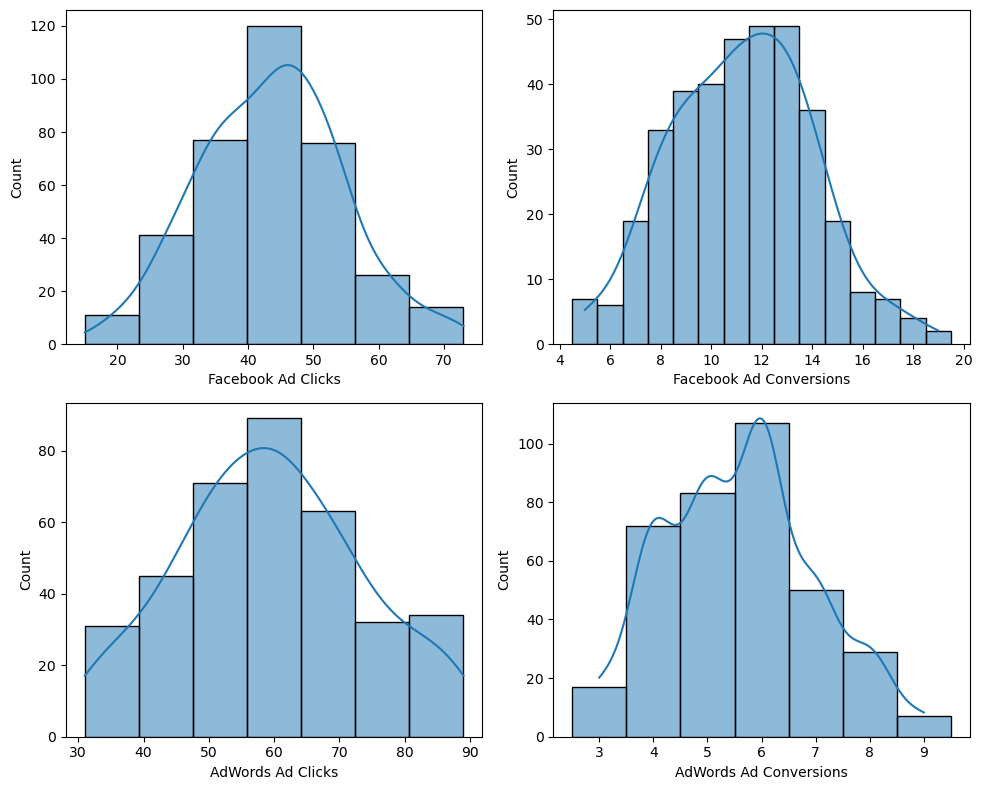

In [118]:
# Distribution of clicks and conversions
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
sns.histplot(df['Facebook Ad Clicks'], bins=7, kde=True)

plt.subplot(2,2,2)
sns.histplot(df['Facebook Ad Conversions'], discrete=True, kde=True)


plt.subplot(2,2,3)
sns.histplot(df['AdWords Ad Clicks'],  bins=7, kde=True)

plt.subplot(2,2,4)
sns.histplot(df['AdWords Ad Conversions'], discrete=True, kde=True)

plt.tight_layout()
plt.show()

**1. Facebook Ad Clicks & Conversions (Top Row)**

* **Ad Clicks:** Shows a clean, relatively symmetric **Normal (Gaussian) Distribution** centered around 40–45 clicks per day. The data is well-behaved, making it ideal for parametric tests (like a T-test).

* **Ad Conversions:** Also follows a normal distribution curve centered around 11–12 conversions. However, because conversions are discrete integers, forcing them into continuous bins creates a slightly blocky look, though the underlying bell curve is clear.

**2. AdWords Ad Clicks & Conversions (Bottom Row)**

* **Ad Clicks:** Displays a classic normal distribution centered tightly around 55–60 clicks. The distribution looks solid, meaning variance is stable across the year.

* **Ad Conversions (The Visual Issue):** Look closely at the bottom-right chart. It looks incredibly blocky and has jagged peaks.

    * **Why this is happening:** AdWords conversions are low discrete numbers (mostly ranging tightly between 3 and 9 per day). Forcing a small range of whole numbers into 7 arbitrary continuous bins makes the math conflict, resulting in uneven bar widths and artificial spikes.

**Statistical Takeaway for your A/B Test:**

Because all four metrics closely follow a **Normal Distribution**, you have officially validated a key assumption required for standard parametric hypothesis testing. You are perfectly clear to proceed with a **Paired Two-Sample T-Test** to compare the means!

> Low-range counts (like our conversions) must be treated as discrete to avoid breaking the chart visually, while high-range counts (like our clicks or views) are safe to treat as continuous because the bins smooth them out into a clean, readable macroeconomic trend. We should eliminate the `bins` and use `discrete=True` for low-range counts.

---
### 📊 How Frequently Do Campaigns Hit High vs. Low Conversion Tiers?

In [119]:
# Creating a function to calculate the category for conversions (binning)
def create_conversion_category(conversion_col):
    category = []
    for conversion in conversion_col:
        if conversion < 6:
            category.append('less than 6')
        elif 6 <= conversion < 11:
            category.append('6 - 10')
        elif 11 <= conversion < 16:
            category.append('10 - 15')
        else:
            category.append('more than 15')
    return category

In [120]:
# Applying function to campaign ad conversions
df['Facebook Conversion Category'] = create_conversion_category(df['Facebook Ad Conversions'])
df['AdWords Conversion Category'] = create_conversion_category(df['AdWords Ad Conversions'])

df[['Facebook Ad Conversions', 'Facebook Conversion Category', 'AdWords Ad Conversions', 'AdWords Conversion Category']].head()

,Facebook Ad Conversions,Facebook Conversion Category,AdWords Ad Conversions,AdWords Conversion Category
0,13,10 - 15,5,less than 6
1,10,6 - 10,6,6 - 10
2,13,10 - 15,3,less than 6
3,13,10 - 15,7,6 - 10
4,12,10 - 15,5,less than 6


In [121]:
df['Facebook Conversion Category'].value_counts()

Facebook Conversion Category
10 - 15         200
6 - 10          137
more than 15     21
less than 6       7
Name: count, dtype: int64

In [122]:
facebook = pd.DataFrame(df['Facebook Conversion Category'].value_counts()).reset_index().rename(columns={'Facebook Conversion Category': 'Category'})
facebook

,Category,count
0,10 - 15,200
1,6 - 10,137
2,more than 15,21
3,less than 6,7


In [123]:
adwords = pd.DataFrame(df['AdWords Conversion Category'].value_counts()).reset_index().rename(columns={'AdWords Conversion Category': 'Category'})
adwords

,Category,count
0,6 - 10,193
1,less than 6,172


> Since we had to merge, the column was renamed for both df to `Category`.

In [124]:
category_df = pd.merge(facebook, adwords, on='Category', how='outer').rename(
    columns={'count_x': 'Facebook Count', 'count_y': 'AdWords Count'}).fillna(0)
category_df

,Category,Facebook Count,AdWords Count
0,10 - 15,200,0.0
1,6 - 10,137,193.0
2,less than 6,7,172.0
3,more than 15,21,0.0


In [125]:
category_df = category_df.iloc[[2,1,0,3]]
category_df

,Category,Facebook Count,AdWords Count
2,less than 6,7,172.0
1,6 - 10,137,193.0
0,10 - 15,200,0.0
3,more than 15,21,0.0


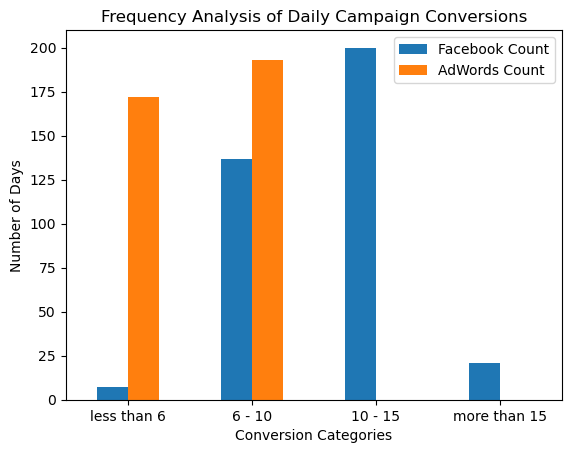

In [126]:
category_df.plot(x='Category', kind='bar')
plt.title('Frequency Analysis of Daily Campaign Conversions')
plt.xlabel('Conversion Categories')
plt.ylabel('Number of Days')
plt.xticks(rotation=0)
plt.show()

The chart instantly exposes a major difference in how your two ad platforms are performing:

- **AdWords (Orange)**: Is heavily weighted to the left. On nearly all days of the year, it generates low-volume conversion days (less than 6 or 6 - 10). It has a hard ceiling and never crosses into the higher tiers.

- **Facebook (Blue)**: Is heavily weighted to the right. It rarely experiences low-performing days. Instead, on the vast majority of days out of the year, it delivers high-volume performance (10 - 15 or more than 15 conversions).

---
### 📊 Do more clicks on the ads really lead to more sales?

- We try to find if clicks and conversions have any correlation.

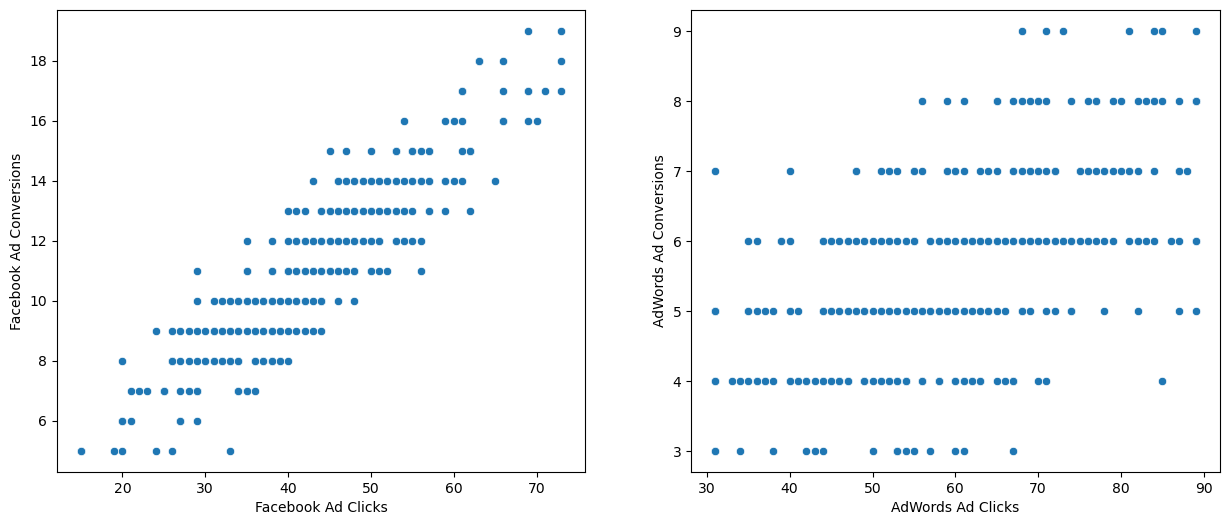

In [128]:
plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
sns.scatterplot(df, y='Facebook Ad Conversions', x='Facebook Ad Clicks')
plt.subplot(1,2,2)
sns.scatterplot(df, y='AdWords Ad Conversions', x='AdWords Ad Clicks')
plt.show()

In [132]:
facebook_corr = df['Facebook Ad Conversions'].corr(df['Facebook Ad Clicks'])
adwords_corr = df['AdWords Ad Conversions'].corr(df['AdWords Ad Clicks'])

In [136]:
print('Correlation Coefficient: \n------------------------------')
print(f'Facebook: {facebook_corr:.2f}')
print(f'AdWords: {adwords_corr:.2f}')

Correlation Coefficient: 
------------------------------
Facebook: 0.91
AdWords: 0.56


**1. Facebook ($0.91$) $\rightarrow$ Strong Positive Correlation**

A value of **$0.91$** is incredibly close to $1.0$ (which would be a perfect straight line).

* **The Meaning:** There is a highly reliable, linear relationship between clicks and conversions on Facebook.
* **The Visual:** If you look at your left scatter plot, the data points tightly cluster together as they move upward and to the right.
* **The Business Takeaway:** Scale is predictable here. If you increase budget to get more clicks on Facebook, you can confidently expect a proportionate rise in conversions.

**2. AdWords ($0.56$) $\rightarrow$ Moderate Positive Correlation**

A value of **$0.56$** means there is still a positive relationship, but it is much weaker and more erratic.

* **The Meaning:** More clicks on AdWords *generally* mean more conversions, but it's not a guarantee. There's a lot of "noise" in the data.
* **The Visual:** If you look at your right scatter plot, the data points are widely scattered and banded horizontally. A day with 40 clicks could yield 3 conversions or 6 conversions; a day with 80 clicks might still yield those same numbers.
* **The Business Takeaway:** Clicks on AdWords are less efficient indicators of success. Getting more traffic from AdWords doesn't cleanly translate to more sales, implying that traffic quality might fluctuate or the intent isn't as solid as Facebook's.

---

## 4. Hypothesis Testing
---

#### Objective

While visual analysis indicates that Facebook generates a higher volume of daily conversions than AdWords, we must determine if this difference is statistically significant or merely the result of random variation. We will conduct a **One-Tailed Paired Two-Sample T-Test** ($\alpha = 0.05$) on our 365 days of synchronized campaign data.

#### Hypotheses Formulations

*   **Null Hypothesis ($H_0$):** There is no significant difference between the average daily conversions of Facebook and AdWords. Any observed difference is due to random chance.
    $$H_0: \mu_{FB} = \mu_{AW}$$

*   **Alternative Hypothesis ($H_1$):** Facebook yields a significantly higher average of daily conversions than AdWords (one-tailed test).
    $$H_1: \mu_{FB} > \mu_{AW}$$



---
#### Verifying the Normality Assumption

In a paired t-test, we do not evaluate the two individual datasets independently. Instead, we calculate the **exact difference row-by-row** (e.g., Day 1 Facebook minus Day 1 AdWords) to isolate a single metric: the **"Daily Performance Gap."** 

The t-test then evaluates whether the *mean* of this difference column is significantly different from zero ($0$).


In [138]:
# Create the difference column
df['Conversion_Difference'] = df['Facebook Ad Conversions'] - df['AdWords Ad Conversions']

# Display basic stats
df['Conversion_Difference'].describe()

count    365.000000
mean       5.660274
std        3.131668
min       -3.000000
25%        3.000000
50%        6.000000
75%        8.000000
max       14.000000
Name: Conversion_Difference, dtype: float64

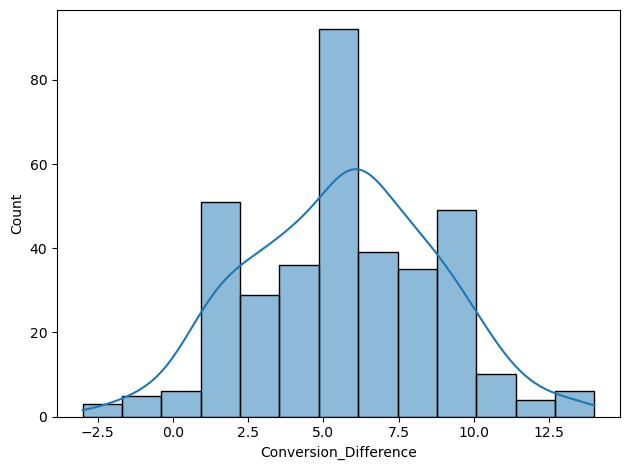

In [143]:
sns.histplot(df['Conversion_Difference'], kde=True)
plt.tight_layout()
plt.show()

> Normal Distribution Verified: The Kernel Density Estimate (KDE) curve shows a symmetric bell shape centered right around 5.6 (which matches the calculated sample mean of 5.66). This completely justifies using a parametric paired t-test.

#### Assumptions Verified

Before running the test, our previous exploratory data analysis verified that:

1. The difference between the two groups is normally distributed.

2. The continuous data consists of a large sample size ($n = 365$), fulfilling the criteria for a parametric t-test.

---

In [149]:
# Run the Paired Two-Sample T-Test
# Note: stats.ttest_rel performs a two-tailed test by default
t_stat, p_value_2tailed = stats.ttest_rel(df['Facebook Ad Conversions'], df['AdWords Ad Conversions'])

# Convert to a One-Tailed P-Value (Since our alternative hypothesis is FB > AW)
# We divide by 2 because the distribution is symmetric, and check if t_stat is positive
p_value_1tailed = (p_value_2tailed / 2) if t_stat > 0 else 1 - (p_value_2tailed / 2) 

print(f"T-statistic         : {t_stat:.4f}")
print(f"Two-tailed P-value  : {p_value_2tailed}")
print(f"One-tailed P-value  : {p_value_1tailed}")

T-statistic         : 34.5309
Two-tailed P-value  : 6.819677418824743e-117
One-tailed P-value  : 3.409838709412372e-117


In [150]:
alpha = 0.05
if p_value_1tailed < alpha:
    print(f'We Reject the Null Hypothesis (p < {alpha}).\nEvidence strongly supports that Facebook significantly outperforms AdWords.')
else:
    print(f'We fail to Reject the Null Hypothesis (p >= {alpha}).\nThere is no statistically significant difference between the two platforms.')

We Reject the Null Hypothesis (p < 0.05).
Evidence strongly supports that Facebook significantly outperforms AdWords.


We are executing a **One-Tailed Paired Two-Sample T-Test**. This code calculates whether the average daily conversion numbers from Facebook are statistically higher than those from AdWords.

**Running the Base Test**

```python
t_stat, p_value_2tailed = stats.ttest_rel(df['Facebook Ad Conversions'], df['AdWords Ad Conversions'])

```

* **`stats.ttest_rel(...)`**: This function runs a **paired (related) t-test**. It looks at the daily difference for each of your 365 days ($Facebook - AdWords$) and tests whether the mean of those differences is significantly different from 0.
* **The Default Behavior**: By default, SciPy's t-test functions are **two-tailed**. They only check if the two platforms are *different* (i.e., Facebook could be significantly better *or* significantly worse). It returns:
* `t_stat`: The calculated T-statistic (which tells you how many standard errors the sample mean difference is away from 0).
* `p_value_2tailed`: The probability of seeing this data if there was actually absolutely no difference between the platforms.

**Converting to a One-Tailed Test**

Because your alternative hypothesis specifically states that **Facebook outperforms AdWords** ($\text{Facebook} > \text{AdWords}$), you only care about one direction (the upper tail).

```python
p_value_1tailed = (p_value_2tailed / 2) if t_stat > 0 else 1 - (p_value_2tailed / 2)

```

* **`p_value_2tailed / 2`**: Since the t-distribution is perfectly symmetrical, the probability of the effect being in *one specific direction* is exactly half of the two-tailed probability.
* **`if t_stat > 0`**: A positive T-statistic confirms that the sample mean of Facebook conversions is higher than AdWords. If `t_stat` is positive, we split the p-value in half to get our one-tailed significance.
* **`else 1 - ...`**: If the T-statistic were negative (meaning AdWords actually performed better), it would mean the evidence is moving in the completely opposite direction of your hypothesis, resulting in a massive p-value close to 1.


**The Output Summary**

The results show an incredibly strong statistical effect:

* **T-statistic ($34.5309$)**: This is an exceptionally large value, meaning the difference in favor of Facebook is massive relative to the day-to-day variance.
* **One-tailed P-value ($\approx 3.41 \times 10^{-117}$)**: This value is effectively zero ($0.000...$ with 116 zeros). It means the probability that this difference happened purely by random chance is completely microscopic, giving you overwhelming statistical justification to reject the null hypothesis in cell `[150]`.